<a href="https://colab.research.google.com/github/Tejal-singhh/internship-tasks/blob/main/Task1-EDA-Retail-Sales/Tejalsingh_Task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving archive (2).zip to archive (2).zip


In [2]:
import zipfile

with zipfile.ZipFile("archive (2).zip", 'r') as zip_ref:
    zip_ref.extractall("retail_data")

import os
print(os.listdir("retail_data"))

['retail_sales_dataset.csv']


In [3]:
import pandas as pd

df = pd.read_csv("retail_data/retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
print("Shape:", df.shape)
df.info()

Shape: (1000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


The dataset has 1000 rows and 9 columns, with a mix of numeric, text, and date columns.

In [5]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


There are no missing values in any column, so no cleaning was needed here.

In [6]:
df['Date'] = pd.to_datetime(df['Date'])
df.dtypes

,0
Transaction ID,int64
Date,datetime64[ns]
Customer ID,object
Gender,object
Age,int64
Product Category,object
Quantity,int64
Price per Unit,int64
Total Amount,int64


In [7]:
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


Total Amount has a mean of 456 but a median of only 135, showing the data is right-skewed — most purchases are small, but a few large purchases pull the average up.

In [8]:
df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].mode().iloc[0]

,0
Age,43.0
Quantity,4.0
Price per Unit,50.0
Total Amount,50.0


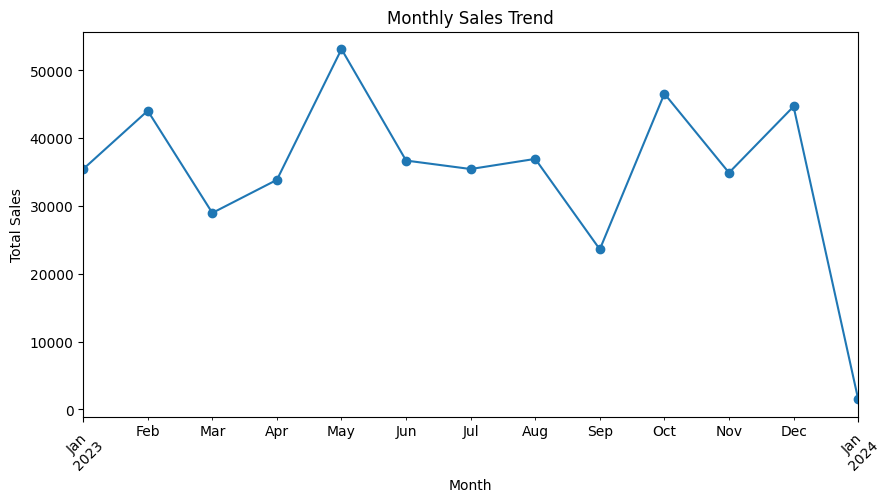

In [9]:
import matplotlib.pyplot as plt

monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()

monthly_sales.plot(kind='line', marker='o', figsize=(10,5))
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

Monthly sales fluctuate noticeably, peaking in May (~53,000) and dropping to their lowest in September (~24,000), suggesting some kind of seasonal or demand-driven variation.

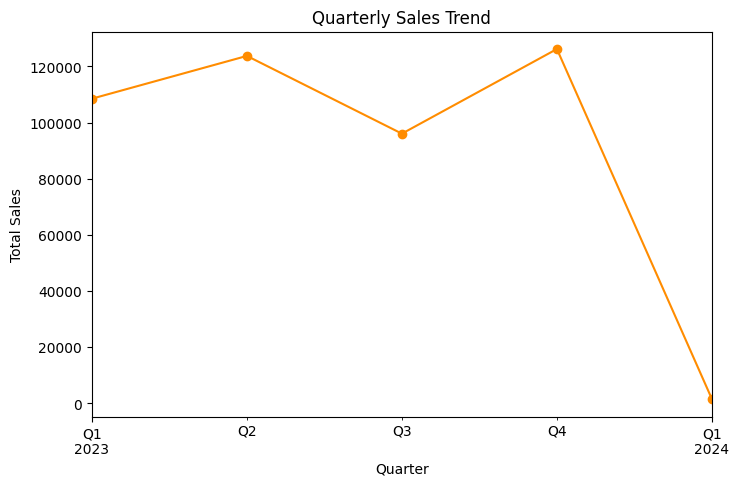

In [10]:
quarterly_sales = df.groupby(df['Date'].dt.to_period('Q'))['Total Amount'].sum()

quarterly_sales.plot(kind='line', marker='o', color='darkorange', figsize=(8,5))
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.show()

Sales rise through Q1–Q4 2023 with a dip in Q3, but the sharp drop shown in "Q1 2024" isn't a real decline — it's because the dataset only contains a single day of 2024 data.

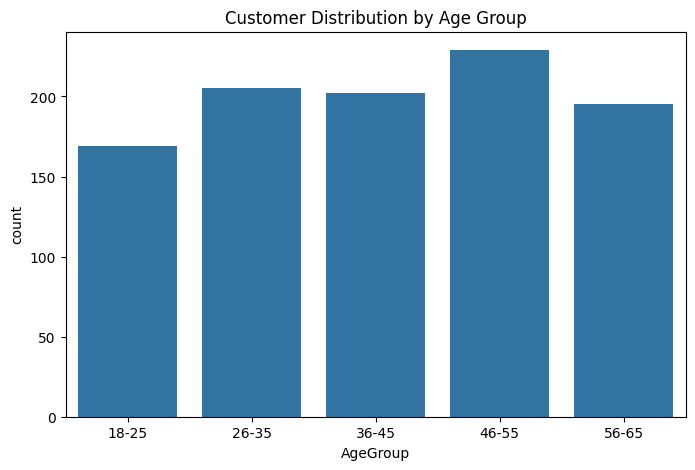

In [11]:
import seaborn as sns

bins = [17, 25, 35, 45, 55, 65]
labels = ['18-25','26-35','36-45','46-55','56-65']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='AgeGroup', order=labels)
plt.title('Customer Distribution by Age Group')
plt.show()

Customers are fairly evenly spread across age groups, with the 46–55 bracket slightly the largest and 18–25 the smallest — age isn't a strongly defining factor for this customer base.

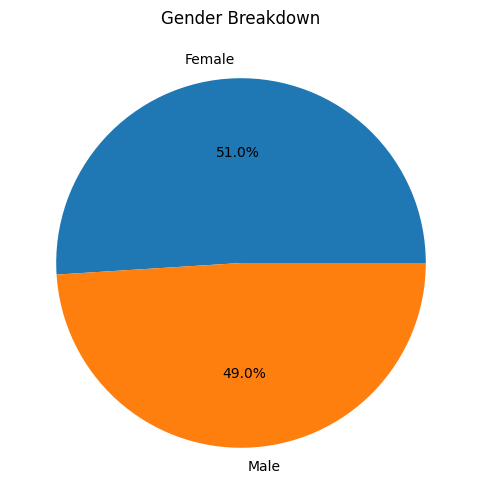

In [12]:
plt.figure(figsize=(6,6))
gender_counts = df['Gender'].value_counts()
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%')
plt.title('Gender Breakdown')
plt.show()

The customer base is almost perfectly split between Male (49%) and Female (51%), showing no gender skew overall.

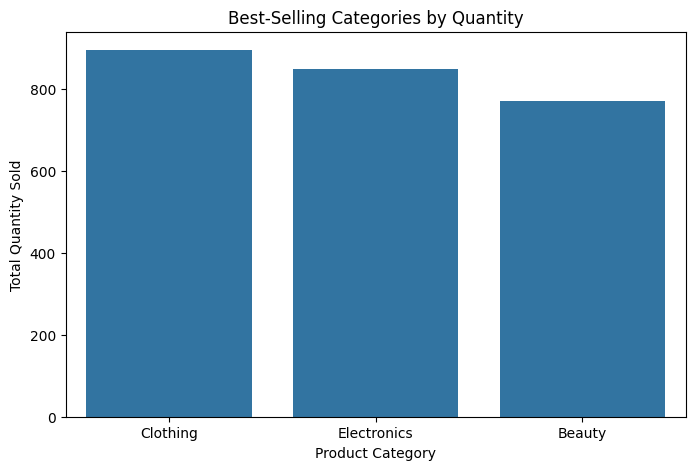

In [13]:
top_products = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=top_products.index, y=top_products.values)
plt.title('Best-Selling Categories by Quantity')
plt.ylabel('Total Quantity Sold')
plt.show()

Clothing has the highest quantity sold (~900 units), followed closely by Electronics (~850) and then Beauty (~770).

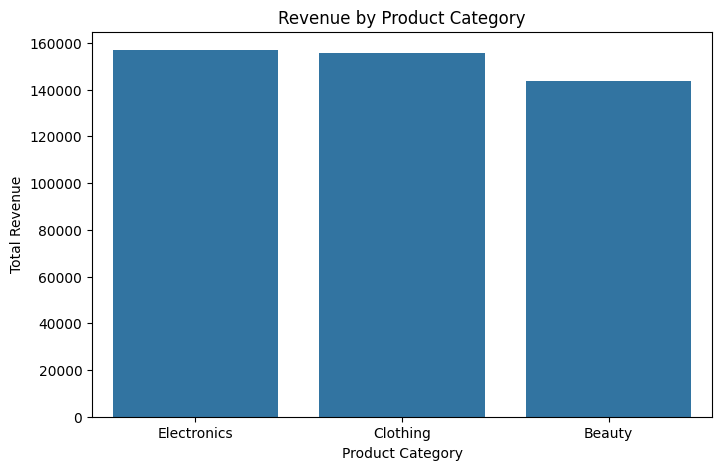

In [14]:
category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=category_revenue.index, y=category_revenue.values)
plt.title('Revenue by Product Category')
plt.ylabel('Total Revenue')
plt.show()

Despite selling fewer units than Clothing, Electronics generates the highest total revenue, since its items are priced higher on average — quantity sold and money earned don't always point to the same "top" category.

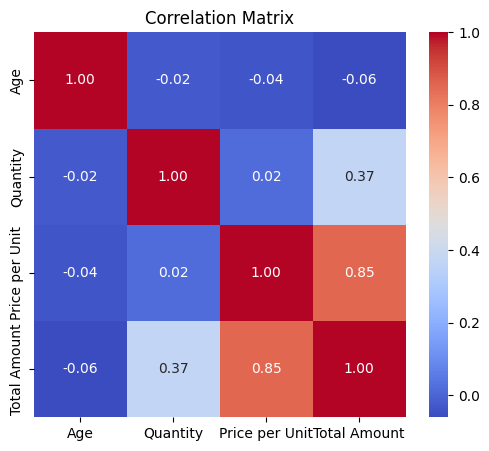

In [15]:
plt.figure(figsize=(6,5))
corr = df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

Price per Unit and Total Amount are strongly correlated (0.85), meaning higher-priced items are the main driver of bill size, more so than quantity (0.37). Age shows almost no correlation with spending.

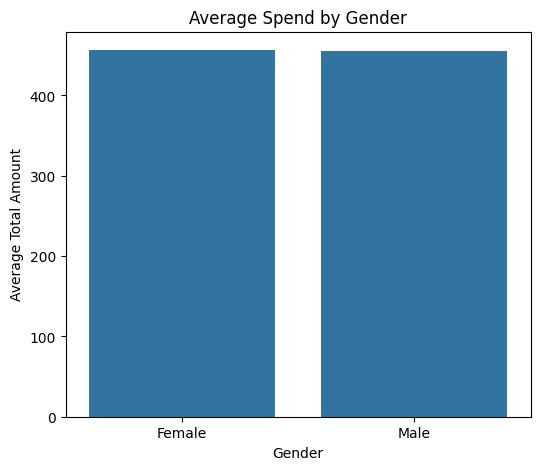

In [16]:
gender_avg = df.groupby('Gender')['Total Amount'].mean()

plt.figure(figsize=(6,5))
sns.barplot(x=gender_avg.index, y=gender_avg.values)
plt.title('Average Spend by Gender')
plt.ylabel('Average Total Amount')
plt.show()

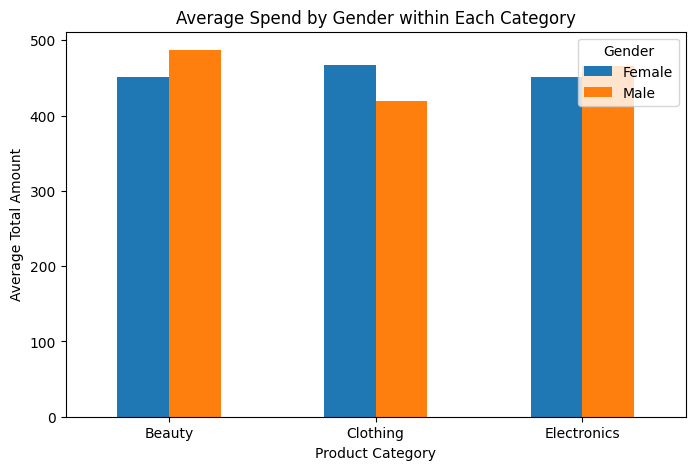

In [17]:
pivot = df.groupby(['Product Category', 'Gender'])['Total Amount'].mean().unstack()

pivot.plot(kind='bar', figsize=(8,5))
plt.title('Average Spend by Gender within Each Category')
plt.ylabel('Average Total Amount')
plt.xticks(rotation=0)
plt.show()

While overall average spend looks nearly identical between genders, breaking it down by category reveals real differences: men spend more on Beauty, women spend more on Clothing — these opposite patterns were cancelling out in the overall average.

Based on this analysis, here are three actionable recommendations:

Promote Electronics as the priority category for revenue growth. It earns the most money despite lower unit sales, meaning even a small increase in Electronics sales volume could meaningfully boost revenue — consider bundling or upselling here.

Run gender-targeted promotions instead of generic ones. Since men spend more on Beauty and women spend more on Clothing, category-specific marketing (e.g., Beauty offers aimed at men, Clothing offers aimed at women) is likely to outperform one-size-fits-all campaigns.

Plan inventory and staffing around the May peak and September dip. Sales swing noticeably month to month, so stocking up ahead of high-demand months like May and scaling back or running promotions during low months like September could improve efficiency and reduce lost sales or excess stock.